In [27]:
import leafmap
import geopandas as gpd

in_geojson = "samples/South West Milan.geojson"
gdf = gpd.read_file(in_geojson)

centroid_coords = gdf["geometry"].centroid
centroid = [
    centroid_coords.y.values[0],
    centroid_coords.x.values[0],
]  # We are going to use the centroid later

m = leafmap.Map(center=centroid, zoom=13)
m.add_geojson(in_geojson)
m

Map(center=[np.float64(45.446287000000005), np.float64(9.167787999999998)], controls=(ZoomControl(options=['po…

In [28]:
from eotdl.access import SUPPORTED_COLLECTION_IDS

SUPPORTED_COLLECTION_IDS

['sentinel-1-grd',
 'sentinel-2-l1c',
 'sentinel-2-l2a',
 'dem',
 'hls',
 'landsat-ot-l2']

In [34]:
from eotdl.access import search_sentinel_imagery
from datetime import datetime, timedelta

end_date = datetime.now() - timedelta(days=50)
start_date = end_date - timedelta(days=10)

time_interval = (start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d"))

r = search_sentinel_imagery(time_interval, gdf.total_bounds.tolist(), "sentinel-2-l2a")
response = list(r)
response

[{'id': 'S2B_MSIL2A_20251226T102339_N0511_R065_T32TNR_20251226T141529',
  'properties': {'datetime': '2025-12-26T10:28:13Z', 'eo:cloud_cover': 7.95}},
 {'id': 'S2A_MSIL2A_20251223T102501_N0511_R065_T32TNR_20251223T120911',
  'properties': {'datetime': '2025-12-23T10:28:32Z', 'eo:cloud_cover': 99.94}},
 {'id': 'S2C_MSIL2A_20251221T102441_N0511_R065_T32TNR_20251221T142411',
  'properties': {'datetime': '2025-12-21T10:28:21Z', 'eo:cloud_cover': 89.06}}]

In [35]:
from eotdl.access import download_sentinel_imagery

download_sentinel_imagery(
    "samples/Milan", '2025-12-26', gdf.total_bounds.tolist(), "sentinel-2-l2a"
)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.102].


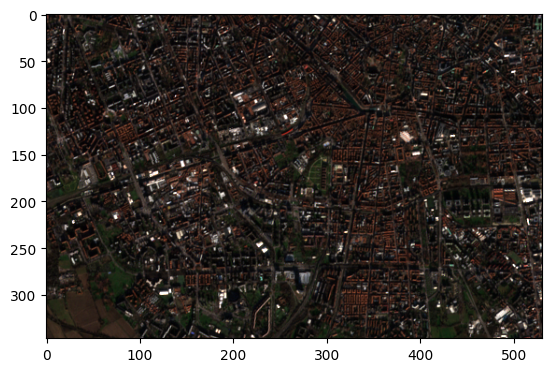

<Axes: >

In [36]:
from rasterio.plot import show
import rasterio

show(rasterio.open("samples/Milan/sentinel-2-l2a_2025-12-26.tiff").read((4,3,2)) / 4000)
